In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =========================================
# LSTM for Hourly Price Prediction
# =========================================

# -------------------------
# 1) Load & prepare data
# -------------------------

In [ ]:
CSV_PATH = "/content/drive/MyDrive/ENGG680 Project Dataset/Table_Full Data_data 2.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)

In [ ]:
len(df)

33120

In [ ]:
# Keep only what's needed (time + price)
df = df[["Date (MST)", "Price"]].copy()

In [ ]:
# Parse datetime, sort, set index
df["Date (MST)"] = pd.to_datetime(df["Date (MST)"], errors="coerce")
df = df.dropna(subset=["Date (MST)", "Price"]).sort_values("Date (MST)").set_index("Date (MST)")

In [ ]:
# Remove duplicate timestamps
df = df[~df.index.duplicated(keep="first")]

In [ ]:
# Check missing values before interpolation (optional for report)
print("Missing Price values before cleaning:", df["Price"].isna().sum())

Missing Price values before cleaning: 0


In [ ]:
# Resample to hourly in case of irregular spacing; interpolate missing values
df = df.resample("h").mean()
df["Price"] = df["Price"].interpolate(method="time").ffill().bfill()

In [ ]:
# Double-check after interpolation
print("Missing Price values after cleaning:", df["Price"].isna().sum())

Missing Price values after cleaning: 0


# -------------------------
# 2) Train / test split
# -------------------------

In [ ]:
# 70% train, 10% val, 20% test
train_end   = int(len(df) * 0.7)
val_end     = int(len(df) * 0.8)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

In [ ]:
scaler_y = MinMaxScaler()

y_train = scaler_y.fit_transform(train_df[["Price"]])
y_val   = scaler_y.transform(val_df[["Price"]])
y_test  = scaler_y.transform(test_df[["Price"]])

# -------------------------
# 3) Make supervised sequences
# -------------------------

In [ ]:
LOOKBACK = 24 * 7  # 168 hours

def make_sequences(series_2d, lookback):
    X, y = [], []
    for i in range(lookback, len(series_2d)):
        X.append(series_2d[i - lookback:i, :])
        y.append(series_2d[i, :])
    return np.array(X), np.array(y)

X_train, y_train_seq = make_sequences(y_train, LOOKBACK)
X_val,   y_val_seq   = make_sequences(y_val,   LOOKBACK)
X_test,  y_test_seq  = make_sequences(y_test,  LOOKBACK)

print(f"Train sequences: X={X_train.shape}, y={y_train_seq.shape}")
print(f"Val   sequences: X={X_val.shape},   y={y_val_seq.shape}")
print(f"Test  sequences: X={X_test.shape},  y={y_test_seq.shape}")

Train sequences: X=(32943, 168, 1), y=(32943, 1)
Val   sequences: X=(4562, 168, 1),   y=(4562, 1)
Test  sequences: X=(9293, 168, 1),  y=(9293, 1)


# -------------------------
# 4) Build & train model
# -------------------------

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_seq,
    validation_data=(X_val, y_val_seq),
    epochs=50,
    batch_size=64,
    shuffle=False,
    callbacks=[es],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0135 - val_loss: 0.0082
Epoch 2/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 3/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0041 - val_loss: 0.0050
Epoch 4/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0038 - val_loss: 0.0050
Epoch 5/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0038 - val_loss: 0.0050
Epoch 6/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0037 - val_loss: 0.0049
Epoch 7/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0038 - val_loss: 0.0050
Epoch 8/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0038 - val_loss: 0.0050
Epoch 9/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0037 - val_loss: 0.0050
Epoch 10/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0037 - val_loss: 0.0049
Epoch 11/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0038 - val_loss: 0.0050
Epoch 12/50
515/515 ━━━━━━━━━━━━━━━━━━━

# ============================
# Plot Train vs Validation Loss
# ============================

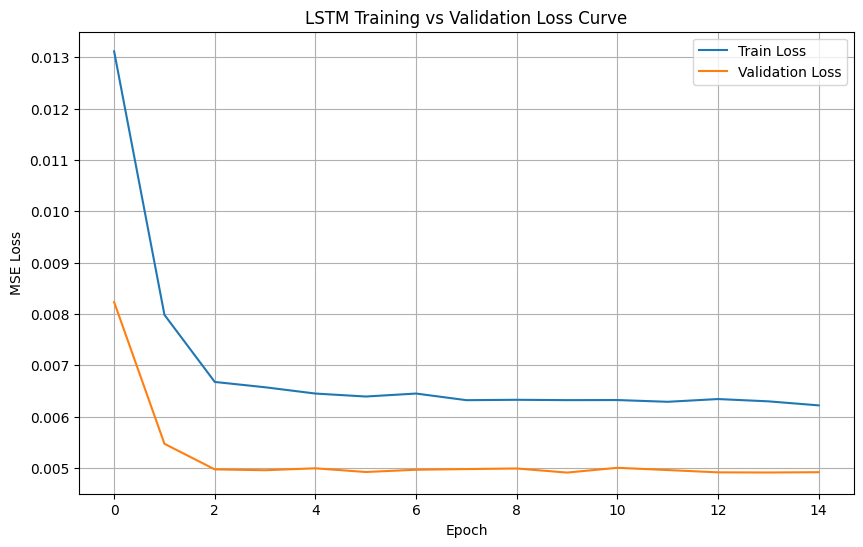

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)

plt.ylim(0.0045, 0.0135)

plt.show()

# -------------------------
# 5) Evaluate on test set
# -------------------------

In [ ]:
y_pred_s = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_s).ravel()
y_true = scaler_y.inverse_transform(y_test_seq).ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

smape = 100 * np.mean(
    2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
)

r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"sMAPE: {smape:.2f}%")
print(f"R²: {r2:.3f}")

291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE : 6.774
RMSE: 31.499
sMAPE: 19.16%
R²: 0.651


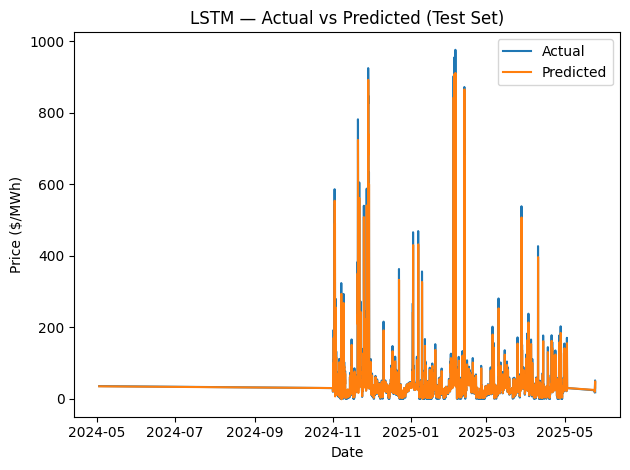

In [ ]:
# Match with datetime index for plotting
test_index = test_df.index[LOOKBACK:] # align to y_test_seq
plot_df = pd.DataFrame({"Actual": y_true, "Predicted": y_pred}, index=test_index)

plt.figure()
plt.plot(plot_df.index, plot_df["Actual"], label="Actual")
plt.plot(plot_df.index, plot_df["Predicted"], label="Predicted")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("LSTM — Actual vs Predicted (Test Set)")
plt.legend(); plt.tight_layout(); plt.show()

# ============================
# Train vs Val vs Test Metrics Table
# ============================

In [ ]:
# TRAIN
y_train_pred_s = model.predict(X_train)
y_train_pred = scaler_y.inverse_transform(y_train_pred_s).ravel()
y_train_true = scaler_y.inverse_transform(y_train_seq).ravel()

# VAL
y_val_pred_s = model.predict(X_val)
y_val_pred = scaler_y.inverse_transform(y_val_pred_s).ravel()
y_val_true = scaler_y.inverse_transform(y_val_seq).ravel()

# TEST
y_test_pred_s = model.predict(X_test)
y_test_pred = scaler_y.inverse_transform(y_test_pred_s).ravel()
y_test_true = scaler_y.inverse_transform(y_test_seq).ravel()

# ---- Metric function ----
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, smape, r2

train_mae, train_rmse, train_smape, train_r2 = compute_metrics(y_train_true, y_train_pred)
val_mae, val_rmse, val_smape, val_r2 = compute_metrics(y_val_true, y_val_pred)
test_mae, test_rmse, test_smape, test_r2 = compute_metrics(y_test_true, y_test_pred)

# ---- Print Table ----
print("=== Train vs Validation vs Test Performance ===")
print(f"{'Metric':<10} {'Train':>15} {'Val':>15} {'Test':>15}")
print("-" * 60)

print(f"{'MAE':<10} {train_mae:15.3f} {val_mae:15.3f} {test_mae:15.3f}")
print(f"{'RMSE':<10} {train_rmse:15.3f} {val_rmse:15.3f} {test_rmse:15.3f}")
print(f"{'sMAPE':<10} {train_smape:15.2f}% {val_smape:15.2f}% {test_smape:15.2f}%")
print(f"{'R²':<10} {train_r2:15.3f} {val_r2:15.3f} {test_r2:15.3f}")

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
=== Train vs Validation vs Test Performance ===
Metric               Train             Val            Test
------------------------------------------------------------
MAE                 30.859          29.717           6.774
RMSE                78.428          70.084          31.499
sMAPE                18.15%           27.57%           19.16%
R²                   0.776           0.761           0.651


# ============================
# Error Distribution Histogram
# ============================

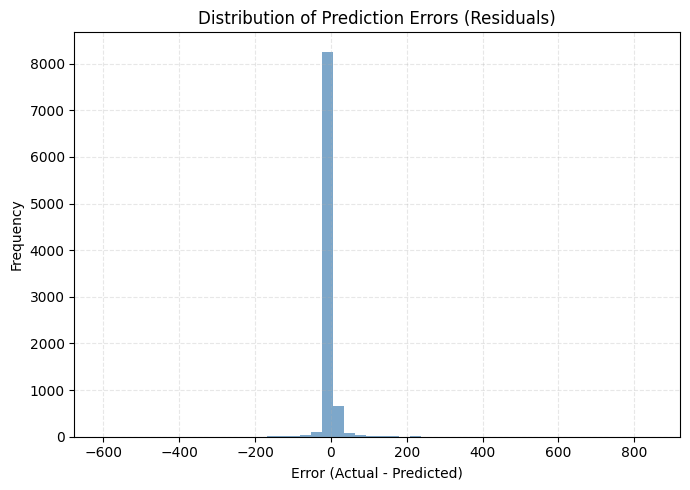

In [ ]:
errors = y_true - y_pred  # test residuals

plt.figure(figsize=(7,5))
plt.hist(errors, bins=50, alpha=0.7, color="steelblue")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================
# Forecast next 24 hours (1 day)
# ==========================

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


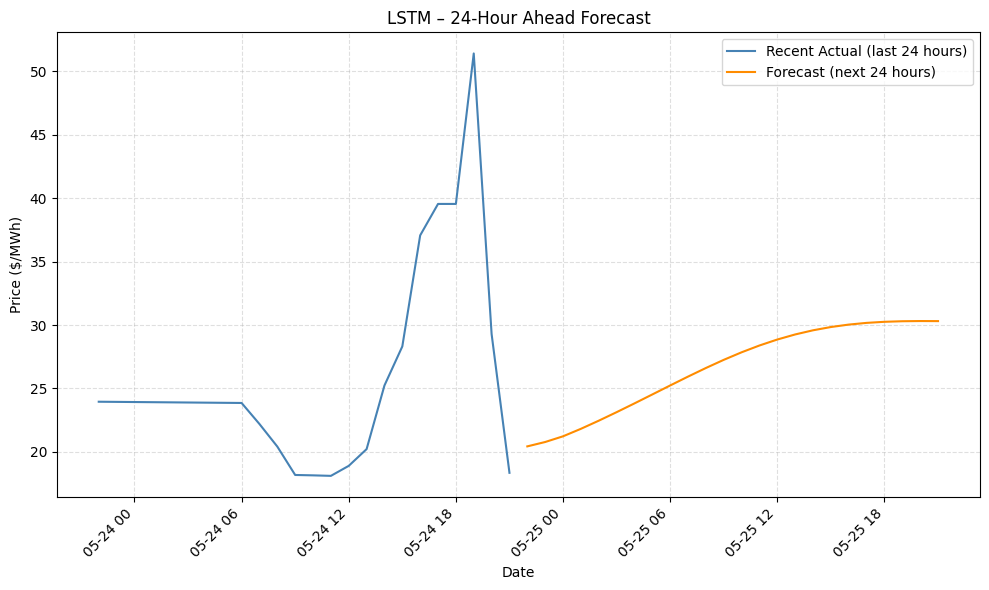

In [ ]:
FORECAST_HOURS = 24  # 24 hours ahead

# Use .values for consistent scaling
last_window = scaler_y.transform(df[["Price"]].iloc[-LOOKBACK:].values)
window = last_window.copy()
future_scaled = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, 1)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_scaled.append(next_scaled)

    # roll window
    window = np.vstack([window[1:], [[next_scaled]]])

# Inverse transform using proper feature name
future_scaled_df = pd.DataFrame(
    np.array(future_scaled).reshape(-1, 1),
    columns=["Price"]
)
future_prices = scaler_y.inverse_transform(future_scaled_df).ravel()

# Future index
future_index = pd.date_range(
    df.index[-1] + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq="h"
)

forecast_df = pd.DataFrame({"Forecast_Price": future_prices}, index=future_index)

plt.figure(figsize=(10,6))

# Plot the most recent 24 hours of actual data
plt.plot(df.index[-24:], df["Price"].iloc[-24:],
         label="Recent Actual (last 24 hours)",
         color="steelblue")

# Plot the next 24-hour forecast
plt.plot(forecast_df.index, forecast_df["Forecast_Price"],
         label="Forecast (next 24 hours)",
         color="darkorange")

plt.title("LSTM – 24-Hour Ahead Forecast")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# -------------------------
# 6) Forecast next 168 hours
# -------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


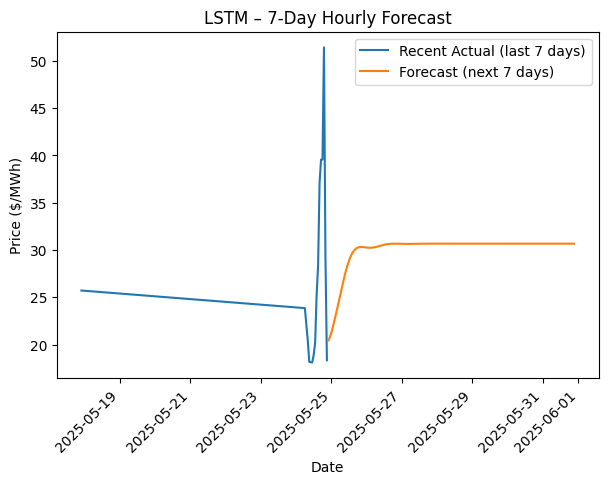

In [ ]:
FORECAST_HOURS = 168  # 7 days ahead

last_window = scaler_y.transform(df[["Price"]].iloc[-LOOKBACK:].values)
window = last_window.copy()
future_scaled = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, 1)
    next_scaled = model.predict(inp, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
    # roll window
    window = np.vstack([window[1:], [[next_scaled]]])

future_prices = scaler_y.inverse_transform(np.array(future_scaled).reshape(-1, 1)).ravel()

future_index = pd.date_range(df.index[-1] + pd.Timedelta(hours=1),
                             periods=FORECAST_HOURS, freq="h")
forecast_df = pd.DataFrame({"Forecast_Price": future_prices}, index=future_index)

plt.figure()
plt.plot(df.index[-7*24:], df["Price"].iloc[-7*24:], label="Recent Actual (last 7 days)")
plt.plot(forecast_df.index, forecast_df["Forecast_Price"], label="Forecast (next 7 days)")
plt.xlabel("Date"); plt.ylabel("Price ($/MWh)")
plt.title("LSTM – 7-Day Hourly Forecast")
plt.legend(); plt.tight_layout();
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45, ha='right')
plt.show()

# ==========================
# PART 7: Seasonal Comparison (Summer vs Winter)
# ==========================

Columns: Index(['Date - MST', 'Hourly Profile1', 'Season1', 'Date (MST)', 'AIL',
       'Gas Price', 'Price', 'Spark Spread'],
      dtype='object')


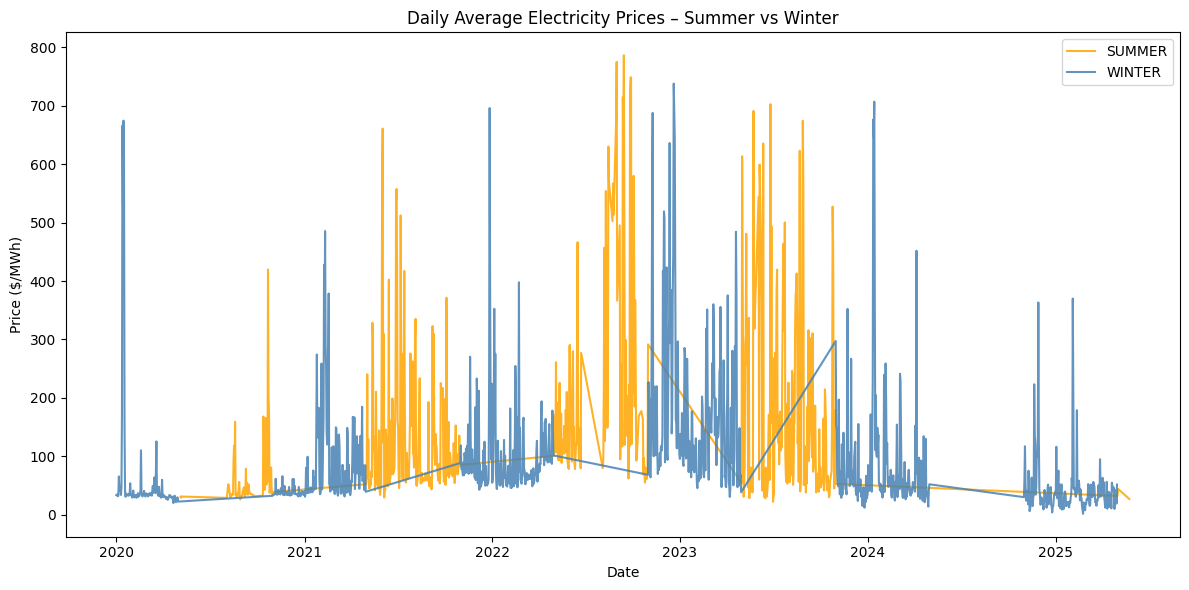

In [ ]:
orig = pd.read_csv("/content/drive/MyDrive/ENGG680 Project Dataset/Table_Full Data_data 2.csv")

# Parse datetime correctly
orig["ParsedDate"] = pd.to_datetime(orig["Date (MST)"], errors="coerce")

# Drop rows where date could not be parsed
orig = orig.dropna(subset=["ParsedDate"])

# Set ParsedDate as index
orig = orig.set_index("ParsedDate")
orig = orig.sort_index()

print("Columns:", orig.columns)

# --- Compute daily price averages with Season1 ---
daily = (
    orig.groupby([orig.index.normalize(), orig["Season1"]])["Price"]
        .mean()
        .reset_index()
)

# Rename the first column to a proper datetime name
daily = daily.rename(columns={"ParsedDate": "Date", 0: "Date"})
daily["Date"] = pd.to_datetime(daily["Date"])

# --- Plot ---
plt.figure(figsize=(12, 6))

for season, color in zip(["SUMMER", "WINTER"], ["orange", "steelblue"]):
    subset = daily[daily["Season1"] == season]
    plt.plot(subset["Date"], subset["Price"], label=season, color=color, alpha=0.85)

plt.title("Daily Average Electricity Prices – Summer vs Winter")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# PART 8 — Prepare Multivariate Feature Set
# (Price + AIL + Gas Price + Season1)
# ============================================

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ---------- Load & basic clean ----------
CSV_PATH = "/content/drive/MyDrive/ENGG680 Project Dataset/Table_Full Data_data 2.csv"
orig = pd.read_csv(CSV_PATH, low_memory=False)

# Parse datetime
orig["ParsedDate"] = pd.to_datetime(orig["Date (MST)"], errors="coerce")
orig = orig.dropna(subset=["ParsedDate"])

# Set index
orig = orig.set_index("ParsedDate").sort_index()

# Keep only needed columns
mv_df = orig[["Price", "AIL", "Gas Price", "Season1"]].copy()

# Map seasonality to numeric (WINTER=0, SUMMER=1)
mv_df["SeasonNum"] = mv_df["Season1"].map({"WINTER": 0, "SUMMER": 1})
mv_df = mv_df.drop(columns=["Season1"])
mv_df = mv_df.rename(columns={"SeasonNum": "Season"})

# ---------- Resample hourly & interpolate (literature-style EPF cleaning) ----------
mv_df = mv_df.resample("H").mean()  # mean on numeric cols
mv_df = mv_df.interpolate(method="time").ffill().bfill()

print("Multivariate df head:")
print(mv_df.head())
print("Columns:", mv_df.columns)


Multivariate df head:
                     Price     AIL  Gas Price  Season
ParsedDate                                           
2020-01-01 00:00:00  30.24  9467.0        1.9     0.0
2020-01-01 01:00:00  29.43  9361.0        1.9     0.0
2020-01-01 02:00:00  29.66  9286.0        1.9     0.0
2020-01-01 03:00:00  28.19  9209.0        1.9     0.0
2020-01-01 04:00:00  31.17  9195.0        1.9     0.0
Columns: Index(['Price', 'AIL', 'Gas Price', 'Season'], dtype='object')


/tmp/ipython-input-2533065622.py:38: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  mv_df = mv_df.resample("H").mean()  # mean on numeric cols


# ====================================
# PART 9 — Train / Val / Test Split
# ====================================

In [ ]:
# 70% train, 10% val, 20% test (time-ordered)
n = len(mv_df)
train_end = int(n * 0.7)
val_end   = int(n * 0.8)

train_df = mv_df.iloc[:train_end].copy()
val_df   = mv_df.iloc[train_end:val_end].copy()
test_df  = mv_df.iloc[val_end:].copy()

# Separate features (X) and target (y)
feature_cols = ["Price", "AIL", "Gas Price", "Season"]
target_col   = "Price"

X_train_raw = train_df[feature_cols].values
X_val_raw   = val_df[feature_cols].values
X_test_raw  = test_df[feature_cols].values

y_train_raw = train_df[[target_col]].values
y_val_raw   = val_df[[target_col]].values
y_test_raw  = test_df[[target_col]].values

# Scale features and target separately (standard practice)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train_raw)
X_val   = scaler_X.transform(X_val_raw)
X_test  = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_val   = scaler_y.transform(y_val_raw)
y_test  = scaler_y.transform(y_test_raw)

print("Scaled shapes:", X_train.shape, y_train.shape)

Scaled shapes: (33111, 4) (33111, 1)


# ============================================
# PART 10 — Create Multivariate Sequences
# ============================================

In [ ]:
LOOKBACK = 24 * 7  # 168 hours

def make_mv_sequences(X_scaled, y_scaled, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X_scaled)):
        X_seq.append(X_scaled[i - lookback:i, :])  # all features in window
        y_seq.append(y_scaled[i, 0])              # next-hour price
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_mv_sequences(X_train, y_train, LOOKBACK)
X_val_seq,   y_val_seq   = make_mv_sequences(X_val,   y_val,   LOOKBACK)
X_test_seq,  y_test_seq  = make_mv_sequences(X_test,  y_test,  LOOKBACK)

print(f"Train seq: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Val   seq: X={X_val_seq.shape}, y={y_val_seq.shape}")
print(f"Test  seq: X={X_test_seq.shape}, y={y_test_seq.shape}")

Train seq: X=(32943, 168, 4), y=(32943,)
Val   seq: X=(4562, 168, 4), y=(4562,)
Test  seq: X=(9293, 168, 4), y=(9293,)


# ============================================
# PART 11A — Build & Train Multivariate LSTM
# ============================================

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

# Number of features
n_features = X_train_seq.shape[2]

# ===== Improved Architecture (same as before) =====
model_mv = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, n_features)),
    Dropout(0.1),

    LSTM(64, return_sequences=False),

    Dense(32, activation="relu"),
    Dense(1)
])

# ===== Optimizer + Loss =====
model_mv.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=Huber()
)

# ===== Early Stopping =====
es = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# ===== Train Model (SHUFFLE = TRUE) =====
history_mv = model_mv.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=80,
    batch_size=32,
    shuffle=True,
    callbacks=[es],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0069 - val_loss: 0.0026
Epoch 2/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 3/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 4/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 5/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 6/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 0.0030 - val_loss: 0.0023
Epoch 7/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0030 - val_loss: 0.0023
Epoch 8/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 9/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 10/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 11/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 12

# ============================
# Extra: Error Distribution Histogram
# ============================

In [ ]:
# ---- Predict on train / val / test (scaled → real values) ----

# Predict function
def predict_split(X_seq, y_seq_scaled):
    y_pred_scaled = model_mv.predict(X_seq)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()
    y_true = scaler_y.inverse_transform(y_seq_scaled.reshape(-1,1)).ravel()
    return y_true, y_pred

# Train
train_true, train_pred = predict_split(X_train_seq, y_train_seq)

# Val
val_true, val_pred = predict_split(X_val_seq, y_val_seq)

# Test
test_true, test_pred = predict_split(X_test_seq, y_test_seq)

print("Shapes:", test_true.shape, test_pred.shape)

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Shapes: (9293,) (9293,)


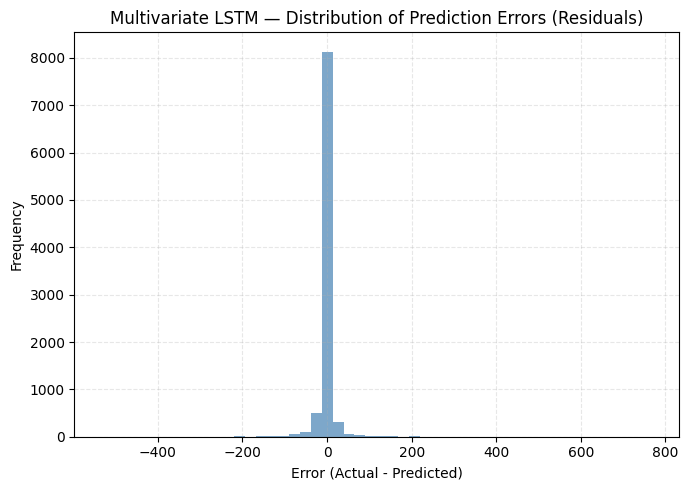

In [ ]:
# --- Compute residuals (test set) ---
errors_mv = test_true - test_pred   # actual - predicted

# --- Plot residual histogram ---
plt.figure(figsize=(7, 5))
plt.hist(errors_mv, bins=50, alpha=0.7, color="steelblue")
plt.title("Multivariate LSTM — Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# PART 11B — Loss Curves
# ============================================

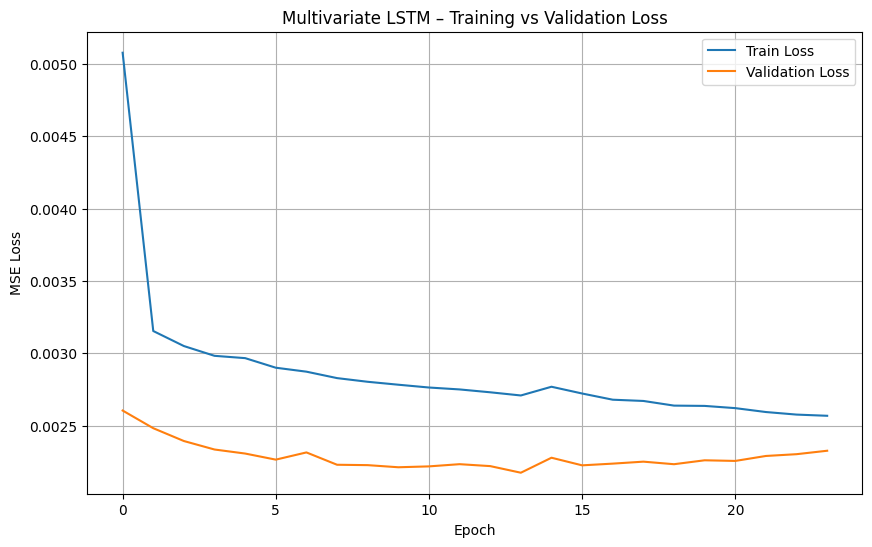

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history_mv.history["loss"],     label="Train Loss")
plt.plot(history_mv.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multivariate LSTM – Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# ADDED: Train vs Val vs Test Metrics Table
# ============================

In [ ]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, smape, r2

# Helper: predict+inverse-scale for a given split
def predict_split(X_seq, y_seq_scaled):
    y_pred_scaled = model_mv.predict(X_seq)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()
    y_true = scaler_y.inverse_transform(y_seq_scaled.reshape(-1,1)).ravel()
    return y_true, y_pred

# Train
train_true, train_pred = predict_split(X_train_seq, y_train_seq)
val_true,   val_pred   = predict_split(X_val_seq,   y_val_seq)
test_true,  test_pred  = predict_split(X_test_seq,  y_test_seq)

train_mae, train_rmse, train_smape, train_r2 = compute_metrics(train_true, train_pred)
val_mae,   val_rmse,   val_smape,   val_r2   = compute_metrics(val_true,   val_pred)
test_mae,  test_rmse,  test_smape,  test_r2  = compute_metrics(test_true,  test_pred)

print("=== Multivariate LSTM – Train vs Val vs Test ===")
print(f"{'Metric':<10} {'Train':>15} {'Val':>15} {'Test':>15}")
print("-"*60)
print(f"{'MAE':<10} {train_mae:15.3f} {val_mae:15.3f} {test_mae:15.3f}")
print(f"{'RMSE':<10} {train_rmse:15.3f} {val_rmse:15.3f} {test_rmse:15.3f}")
print(f"{'sMAPE':<10} {train_smape:15.2f}% {val_smape:15.2f}% {test_smape:15.2f}%")
print(f"{'R²':<10} {train_r2:15.3f} {val_r2:15.3f} {test_r2:15.3f}")

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
=== Multivariate LSTM – Train vs Val vs Test ===
Metric               Train             Val            Test
------------------------------------------------------------
MAE                 32.276          31.602           8.728
RMSE                72.723          65.954          30.086
sMAPE                23.58%           33.12%           25.02%
R²                   0.808           0.789           0.681


# ============================================
# PART 11C — Actual vs Predicted (Test)
# ============================================

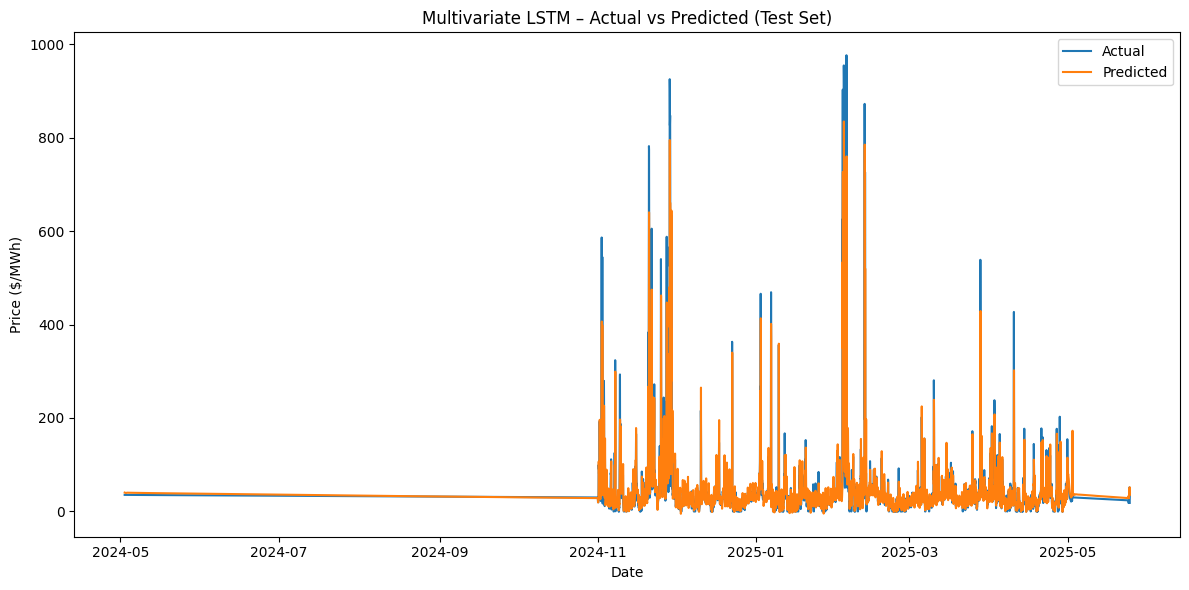

In [ ]:
# Align timestamps for test sequences
test_index = test_df.index[LOOKBACK:]  # same idea as univariate

plot_df_mv = pd.DataFrame({
    "Actual":    test_true,
    "Predicted": test_pred
}, index=test_index)

plt.figure(figsize=(12,6))
plt.plot(plot_df_mv.index, plot_df_mv["Actual"],    label="Actual")
plt.plot(plot_df_mv.index, plot_df_mv["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.title("Multivariate LSTM – Actual vs Predicted (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# PART 12A — 24-Hour Forecast (recursive)
# ============================================

/tmp/ipython-input-1583290569.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index_24 = pd.date_range(


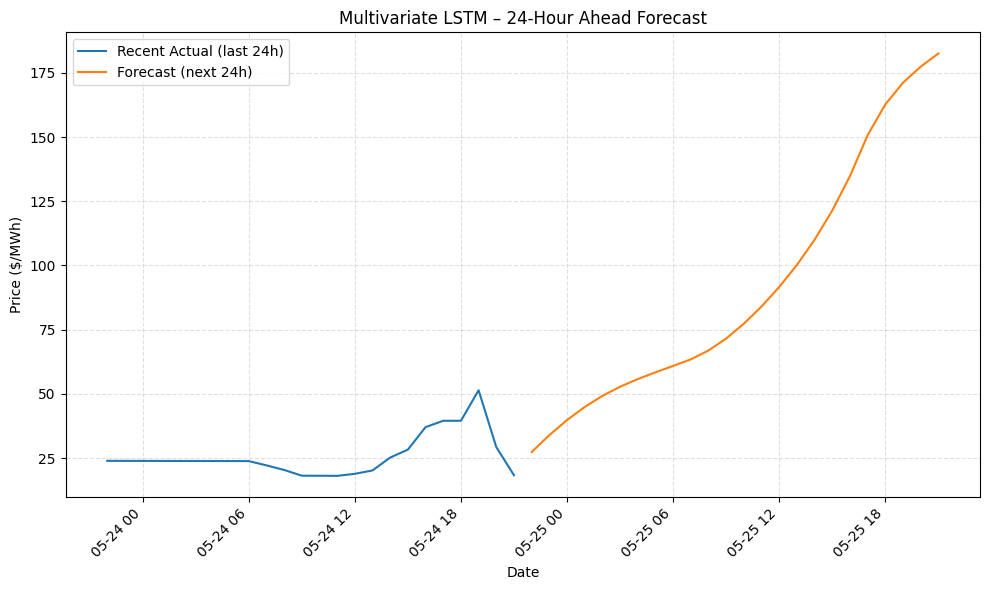

In [ ]:
FORECAST_HOURS = 24

# Build the last window from scaled multivariate features
last_window_X = scaler_X.transform(mv_df[feature_cols].values)[-LOOKBACK:]
window = last_window_X.copy()
future_scaled_prices = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, n_features)
    next_price_scaled = model_mv.predict(inp, verbose=0)[0, 0]
    future_scaled_prices.append(next_price_scaled)

    # update window: replace Price column (0) with predicted price,
    # keep other features at last known values (naive but standard)
    next_row = window[-1].copy()
    next_row[0] = next_price_scaled
    window = np.vstack([window[1:], next_row])

# Inverse-scale future prices
future_prices_mv = scaler_y.inverse_transform(
    np.array(future_scaled_prices).reshape(-1,1)
).ravel()

# Build future index
future_index_24 = pd.date_range(
    mv_df.index[-1] + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq="H"
)

forecast_24_df = pd.DataFrame(
    {"Forecast_Price": future_prices_mv},
    index=future_index_24
)

plt.figure(figsize=(10,6))
plt.plot(mv_df.index[-24:], mv_df["Price"].iloc[-24:], label="Recent Actual (last 24h)")
plt.plot(forecast_24_df.index, forecast_24_df["Forecast_Price"],
         label="Forecast (next 24h)")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.title("Multivariate LSTM – 24-Hour Ahead Forecast")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ============================================
# PART 12B — 7-Day (168-hour) Forecast
# ============================================

/tmp/ipython-input-2517311644.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index_7d = pd.date_range(


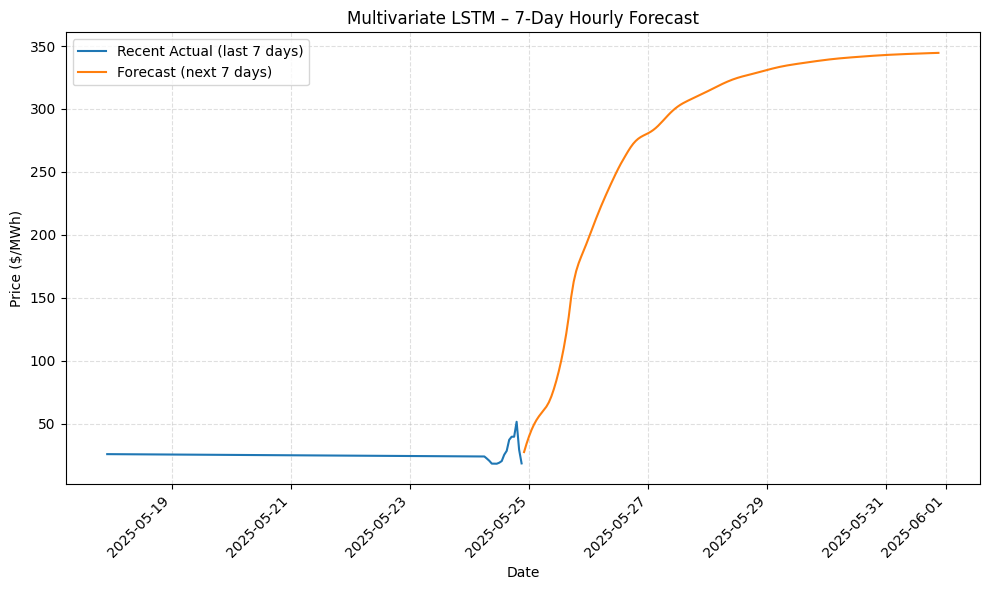

In [ ]:
FORECAST_HOURS = 168  # 7 days

last_window_X = scaler_X.transform(mv_df[feature_cols].values)[-LOOKBACK:]
window = last_window_X.copy()
future_scaled_prices = []

for _ in range(FORECAST_HOURS):
    inp = window.reshape(1, LOOKBACK, n_features)
    next_price_scaled = model_mv.predict(inp, verbose=0)[0, 0]
    future_scaled_prices.append(next_price_scaled)

    next_row = window[-1].copy()
    next_row[0] = next_price_scaled  # update only price
    window = np.vstack([window[1:], next_row])

future_prices_mv_7d = scaler_y.inverse_transform(
    np.array(future_scaled_prices).reshape(-1,1)
).ravel()

future_index_7d = pd.date_range(
    mv_df.index[-1] + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq="H"
)

forecast_7d_df = pd.DataFrame(
    {"Forecast_Price": future_prices_mv_7d},
    index=future_index_7d
)

plt.figure(figsize=(10,6))
plt.plot(mv_df.index[-7*24:], mv_df["Price"].iloc[-7*24:],
         label="Recent Actual (last 7 days)")
plt.plot(forecast_7d_df.index, forecast_7d_df["Forecast_Price"],
         label="Forecast (next 7 days)")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.title("Multivariate LSTM – 7-Day Hourly Forecast")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()